# 🐷 Pig Posture Recognition – ConvNeXt DANN (Domain Adversarial)

**Ansatz:** Domain Adversarial Neural Network (DANN) mit Gradient Reversal Layer  
**Backbone:** ConvNeXt-Base (pretrained, `timm`)  
**GPU:** Multi-GPU Training (Alle verfügbaren GPUs, z.B. 4x Tesla V100)  
**Input:** 288x288 cropped pig instances  
**Metric:** Macro-averaged F1 score

## ⚙️ Configuration

In [1]:
TAG = "T2"

DATA_ROOT = "/datasets/multi-view-pig-posture-recognition"

if TAG == "T1":
    CSV_PATH = f"{DATA_ROOT}/train1.csv"
    IMG_DIR  = f"{DATA_ROOT}/train1_images"
else:
    CSV_PATH = f"{DATA_ROOT}/train2.csv"
    IMG_DIR  = f"{DATA_ROOT}/train2_images"

OUTPUT_DIR = f"runs/convnext_dann_{TAG.lower()}"

MODEL_NAME     = "convnext_base"
IMG_SIZE       = 288
BATCH_SIZE     = 128  # Größerer Batch für 4 GPUs
EPOCHS         = 20
LR             = 3e-4
WARMUP_EPOCHS  = 2
VAL_FRAC       = 0.10
LABEL_SMOOTH   = 0.10
MIXUP_ALPHA    = 0.30
PAD_RATIO      = 0.25
NUM_WORKERS    = 8
SEED           = 42

NUM_CLASSES    = 5
CLASS_NAMES    = ["Lateral_lying_left", "Lateral_lying_right",
                  "Sitting", "Standing", "Sternal_lying"]

LAMBDA_DOMAIN_MAX = 0.1

print(f"Tag: {TAG}  |  Model: {MODEL_NAME}  |  ImgSize: {IMG_SIZE}  |  Batch: {BATCH_SIZE}")

Tag: T2  |  Model: convnext_base  |  ImgSize: 288  |  Batch: 128


## 📦 Install Dependencies

In [2]:
!pip install timm tqdm scikit-learn pandas pillow matplotlib -q

## 📚 Imports & GPU Check

In [3]:
import ast, random, re
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from collections import Counter
import os
import ssl
import urllib3
import requests

# --- SSL Fix für Zertifikat-Fehler (HuggingFace Download) ---
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
ssl._create_default_https_context = ssl._create_unverified_context
old_request = requests.Session.request
def new_request(self, method, url, **kwargs):
    kwargs['verify'] = False
    return old_request(self, method, url, **kwargs)
requests.Session.request = new_request
# ------------------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

import warnings
warnings.filterwarnings("ignore")

NUM_GPUS = torch.cuda.device_count()
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
DEVICE_IDS = list(range(NUM_GPUS))

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPUs detected: {NUM_GPUS}")
if torch.cuda.is_available():
    for i in DEVICE_IDS:
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("⚠️ CUDA nicht verfügbar! Modell wird auf CPU ausgeführt.")

<jemalloc>: Unsupported system page size


CUDA available: True
GPUs detected: 4
  GPU 0: Tesla V100-SXM2-16GB
  GPU 1: Tesla V100-SXM2-16GB
  GPU 2: Tesla V100-SXM2-16GB
  GPU 3: Tesla V100-SXM2-16GB


## 🔒 Reproducibility

In [4]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 🔍 Load Data & Extract Domain IDs

In [5]:
df = pd.read_csv(CSV_PATH)
print(f"Total instances: {len(df)}  |  Unique images: {df['image_id'].nunique()}")

def extract_domain(image_id):
    name = os.path.splitext(image_id)[0]
    match = re.match(r'^(cam\d+|view\d+|camera\d+)', name, re.IGNORECASE)
    if match: return match.group(1).lower()
    match = re.match(r'^(.+?)_?\d+$', name)
    if match: return match.group(1).lower()
    parts = name.split('_')
    if len(parts) > 1: return parts[0].lower()
    return name.lower()

df['domain_str'] = df['image_id'].apply(extract_domain)
domain_names = sorted(df['domain_str'].unique())
domain_to_id = {name: i for i, name in enumerate(domain_names)}
df['domain_id'] = df['domain_str'].map(domain_to_id)

NUM_DOMAINS = len(domain_names)
print(f"\n{NUM_DOMAINS} domains detected:")
for name, did in domain_to_id.items():
    print(f"  {did}: '{name}' → {(df['domain_id'] == did).sum()} instances")

print("\nClass distribution:")
for c in range(NUM_CLASSES):
    cnt = (df["class_id"] == c).sum()
    print(f"  {c} - {CLASS_NAMES[c]:<22} {cnt:>5}  ({100*cnt/len(df):.1f}%)")

Total instances: 23450  |  Unique images: 3150

22 domains detected:
  0: 'pen1_orb_cam1_20250108' → 722 instances
  1: 'pen1_orb_cam2_20250108' → 1488 instances
  2: 'pen1_tur_cam1_20250201' → 80 instances
  3: 'pen1_tur_cam1_20250203' → 120 instances
  4: 'pen1_tur_cam2_20250122' → 1086 instances
  5: 'pen1_tur_cam2_20250125' → 1666 instances
  6: 'pen1_tur_cam2_20250126' → 1271 instances
  7: 'pen1_tur_cam2_20250127' → 1243 instances
  8: 'pen1_tur_cam2_20250201' → 412 instances
  9: 'pen1_tur_cam2_20250202' → 50 instances
  10: 'pen1_tur_cam2_20250203' → 624 instances
  11: 'pen1_tur_cam2_20250207' → 833 instances
  12: 'pen1_tur_cam2_20250220' → 1009 instances
  13: 'pen2_orb_cam1_20250108' → 2817 instances
  14: 'pen2_orb_cam2_20250217' → 120 instances
  15: 'pen2_tur_cam1_20250109' → 5250 instances
  16: 'pen2_tur_cam1_20250120' → 1570 instances
  17: 'pen2_tur_cam1_20250123' → 961 instances
  18: 'pen2_tur_cam1_20250124' → 152 instances
  19: 'pen2_tur_cam1_20250209' → 1744 ins

## 🔄 Gradient Reversal Layer

In [6]:
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.clone()
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None

class GradientReversalLayer(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_
    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)

def get_lambda(epoch, max_epochs):
    p = epoch / max_epochs
    return LAMBDA_DOMAIN_MAX * (2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0)

print("GRL defined.")

GRL defined.


## 🧠 ConvNeXt-DANN Model

In [7]:
class ConvNeXtDANN(nn.Module):
    def __init__(self, model_name, num_classes, num_domains, drop_rate=0.3):
        super().__init__()
        self.features = timm.create_model(model_name, pretrained=True, num_classes=0)
        feat_dim = self.features.num_features
        self.posture_head = nn.Sequential(
            nn.LayerNorm(feat_dim), nn.Dropout(drop_rate),
            nn.Linear(feat_dim, 512), nn.GELU(), nn.Dropout(drop_rate),
            nn.Linear(512, num_classes)
        )
        self.grl = GradientReversalLayer()
        self.domain_head = nn.Sequential(
            nn.LayerNorm(feat_dim), nn.Dropout(drop_rate),
            nn.Linear(feat_dim, 512), nn.GELU(), nn.Dropout(drop_rate),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(drop_rate),
            nn.Linear(256, num_domains)
        )
        print(f"ConvNeXtDANN: feat={feat_dim}, posture={num_classes}, domains={num_domains}")

    def forward(self, x, lambda_=1.0):
        features = self.features(x)
        posture_logits = self.posture_head(features)
        self.grl.lambda_ = lambda_
        domain_logits = self.domain_head(self.grl(features))
        return posture_logits, domain_logits

    def predict_posture(self, x):
        return self.posture_head(self.features(x))

print("Model class defined.")

Model class defined.


## 🗂️ Dataset & Augmentations

In [8]:
class PigPostureDANNDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, pad_ratio=0.25):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.pad_ratio = pad_ratio
    def __len__(self): return len(self.df)
    def _crop(self, img, bbox):
        W, H = img.size
        x, y, w, h = [float(v) for v in ast.literal_eval(bbox)]
        px, py = w * self.pad_ratio, h * self.pad_ratio
        x1 = max(0, int(x - px)); y1 = max(0, int(y - py))
        x2 = min(W, int(x+w+px)); y2 = min(H, int(y+h+py))
        return img.crop((x1, y1, x2, y2))
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row["image_id"])).convert("RGB")
        crop = self._crop(img, row["bbox"])
        if self.transform: crop = self.transform(crop)
        return crop, int(row["class_id"]), int(row["domain_id"])

def get_train_transform(size=IMG_SIZE):
    return T.Compose([
        T.Resize((size + 48, size + 48)), T.RandomCrop(size),
        T.RandomHorizontalFlip(p=0.5), T.RandomVerticalFlip(p=0.3),
        T.RandomRotation(degrees=25),
        T.RandomAffine(degrees=0, scale=(0.85, 1.15)),
        T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.08),
        T.RandomGrayscale(p=0.1),
        T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        T.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    ])

def get_val_transform(size=IMG_SIZE):
    return T.Compose([
        T.Resize((size, size)), T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

print("Dataset defined.")

Dataset defined.


## ✂️ Train / Validation Split

In [9]:
train_df, val_df = train_test_split(
    df, test_size=VAL_FRAC, stratify=df["class_id"], random_state=SEED
)
print(f"Train: {len(train_df)}  |  Val: {len(val_df)}")

train_ds = PigPostureDANNDataset(train_df, IMG_DIR, transform=get_train_transform(), pad_ratio=PAD_RATIO)
val_ds   = PigPostureDANNDataset(val_df,   IMG_DIR, transform=get_val_transform(),   pad_ratio=PAD_RATIO)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print("DataLoaders ready.")

Train: 21105  |  Val: 2345
DataLoaders ready.


## 🧠 Create Model, Loss & Optimizer (Multi-GPU)

In [10]:
model = ConvNeXtDANN(MODEL_NAME, NUM_CLASSES, NUM_DOMAINS)

# Aktiviere DataParallel für alle verfügbaren GPUs
if NUM_GPUS > 1:
    print(f"Verwende nn.DataParallel für {NUM_GPUS} GPUs!")
    model = nn.DataParallel(model, device_ids=DEVICE_IDS)
    
model = model.to(DEVICE)

# Zähle Parameter (unter module bei DataParallel)
base_model = model.module if isinstance(model, nn.DataParallel) else model
print(f"Parameters: {sum(p.numel() for p in base_model.parameters()) / 1e6:.1f}M")

counts = Counter(train_df["class_id"].tolist())
total = len(train_df)
weights = torch.tensor(
    [total / (NUM_CLASSES * max(counts.get(c, 1), 1)) for c in range(NUM_CLASSES)],
    dtype=torch.float32
).to(DEVICE)
print(f"Class weights: {[f'{w:.2f}' for w in weights.cpu()]}")

posture_criterion       = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTH)
posture_criterion_plain = nn.CrossEntropyLoss(weight=weights)
domain_criterion        = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)

def warmup_cosine_schedule(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine_schedule)
scaler = GradScaler()
print("✅ Ready.")

ConvNeXtDANN: feat=1024, posture=5, domains=22
Verwende nn.DataParallel für 4 GPUs!
Parameters: 88.8M
Class weights: ['1.52', '1.37', '6.74', '0.47', '0.74']
✅ Ready.


## 🛠️ Training & Validation Functions

In [11]:
def mixup_data(x, y, alpha=0.3):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_loss(crit, pred, y_a, y_b, lam):
    return lam * crit(pred, y_a) + (1 - lam) * crit(pred, y_b)

def train_one_epoch(model, loader, optimizer, scaler, epoch):
    model.train()
    lam_grl = get_lambda(epoch, EPOCHS)
    p_loss_sum, d_loss_sum = 0.0, 0.0
    p_preds, p_labels, d_preds, d_labels = [], [], [], []
    for imgs, plabels, dlabels in tqdm(loader, desc="  Train", leave=False):
        imgs, plabels, dlabels = imgs.to(DEVICE), plabels.to(DEVICE), dlabels.to(DEVICE)
        mixed, y_a, y_b, lam = mixup_data(imgs, plabels, alpha=MIXUP_ALPHA)
        optimizer.zero_grad()
        with autocast():
            p_logits, d_logits = model(mixed, lambda_=lam_grl)
            p_loss = mixup_loss(posture_criterion_plain, p_logits, y_a, y_b, lam)
            d_loss = domain_criterion(d_logits, dlabels)
            loss = p_loss + d_loss
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        p_loss_sum += p_loss.item() * imgs.size(0)
        d_loss_sum += d_loss.item() * imgs.size(0)
        p_preds.extend(p_logits.argmax(1).cpu().numpy())
        p_labels.extend(y_a.cpu().numpy())
        d_preds.extend(d_logits.argmax(1).cpu().numpy())
        d_labels.extend(dlabels.cpu().numpy())
    n = len(loader.dataset)
    return {'p_loss': p_loss_sum/n, 'd_loss': d_loss_sum/n,
            'p_f1': f1_score(p_labels, p_preds, average='macro', zero_division=0),
            'd_acc': np.mean(np.array(d_preds)==np.array(d_labels)), 'lambda': lam_grl}

@torch.no_grad()
def validate(model, loader, epoch):
    model.eval()
    lam_grl = get_lambda(epoch, EPOCHS)
    p_loss_sum, d_loss_sum = 0.0, 0.0
    p_preds, p_labels, d_preds, d_labels = [], [], [], []
    for imgs, plabels, dlabels in tqdm(loader, desc="  Val  ", leave=False):
        imgs, plabels, dlabels = imgs.to(DEVICE), plabels.to(DEVICE), dlabels.to(DEVICE)
        with autocast():
            p_logits, d_logits = model(imgs, lambda_=lam_grl)
            p_loss = posture_criterion(p_logits, plabels)
            d_loss = domain_criterion(d_logits, dlabels)
        p_loss_sum += p_loss.item() * imgs.size(0)
        d_loss_sum += d_loss.item() * imgs.size(0)
        p_preds.extend(p_logits.argmax(1).cpu().numpy())
        p_labels.extend(plabels.cpu().numpy())
        d_preds.extend(d_logits.argmax(1).cpu().numpy())
        d_labels.extend(dlabels.cpu().numpy())
    n = len(loader.dataset)
    return {'p_loss': p_loss_sum/n, 'd_loss': d_loss_sum/n,
            'p_f1': f1_score(p_labels, p_preds, average='macro', zero_division=0),
            'd_acc': np.mean(np.array(d_preds)==np.array(d_labels))}, p_preds, p_labels

print("Functions defined.")

Functions defined.


## 🚀 Training Loop

In [12]:
best_val_f1 = 0.0
log = []

for epoch in range(1, EPOCHS + 1):
    tm = train_one_epoch(model, train_loader, optimizer, scaler, epoch)
    vm, _, _ = validate(model, val_loader, epoch)
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    mark = "★" if vm['p_f1'] > best_val_f1 else " "
    print(f"{mark} E{epoch:02d}/{EPOCHS} | "
          f"Train p_f1={tm['p_f1']:.4f} d_acc={tm['d_acc']:.3f} | "
          f"Val p_f1={vm['p_f1']:.4f} d_acc={vm['d_acc']:.3f} | "
          f"λ={tm['lambda']:.4f} lr={lr:.2e}")

    log.append(dict(epoch=epoch, train_p_loss=tm['p_loss'], train_p_f1=tm['p_f1'],
                    train_d_loss=tm['d_loss'], train_d_acc=tm['d_acc'],
                    val_p_loss=vm['p_loss'], val_p_f1=vm['p_f1'],
                    val_d_acc=vm['d_acc'], lambda_=tm['lambda'], lr=lr))

    if vm['p_f1'] > best_val_f1:
        best_val_f1 = vm['p_f1']
        
        # Beim Speichern das eigentliche Modell extrahieren falls DataParallel genutzt wird
        model_to_save = model.module if isinstance(model, nn.DataParallel) else model
        
        torch.save({
            "epoch": epoch, "model": model_to_save.state_dict(),
            "optimizer": optimizer.state_dict(),
            "val_f1": vm['p_f1'], "val_domain_acc": vm['d_acc'],
            "model_name": MODEL_NAME, "num_classes": NUM_CLASSES,
            "num_domains": NUM_DOMAINS, "tag": TAG,
            "architecture": "ConvNeXtDANN",
        }, os.path.join(OUTPUT_DIR, "best_model.pth"))
        print(f"  → Saved (f1={vm['p_f1']:.4f}, d_acc={vm['d_acc']:.3f})")

print(f"\n✅ Done. Best Val F1: {best_val_f1:.4f}")
pd.DataFrame(log).to_csv(os.path.join(OUTPUT_DIR, "training_log.csv"), index=False)

★ E01/20 | Train p_f1=0.3614 d_acc=0.260 | Val p_f1=0.7314 d_acc=0.455 | λ=0.0245 lr=3.00e-04
  → Saved (f1=0.7314, d_acc=0.455)


★ E02/20 | Train p_f1=0.4007 d_acc=0.270 | Val p_f1=0.8352 d_acc=0.460 | λ=0.0462 lr=3.00e-04
  → Saved (f1=0.8352, d_acc=0.460)


  E03/20 | Train p_f1=0.4545 d_acc=0.289 | Val p_f1=0.7765 d_acc=0.515 | λ=0.0635 lr=2.98e-04


  E04/20 | Train p_f1=0.5043 d_acc=0.292 | Val p_f1=0.8186 d_acc=0.432 | λ=0.0762 lr=2.91e-04


★ E05/20 | Train p_f1=0.5038 d_acc=0.254 | Val p_f1=0.8767 d_acc=0.372 | λ=0.0848 lr=2.80e-04
  → Saved (f1=0.8767, d_acc=0.372)


...

  E16/20 | Train p_f1=0.5923 d_acc=0.226 | Val p_f1=0.9303 d_acc=0.233 | λ=0.0999 lr=3.51e-05


★ E17/20 | Train p_f1=0.5704 d_acc=0.226 | Val p_f1=0.9313 d_acc=0.230 | λ=0.1000 lr=2.01e-05
  → Saved (f1=0.9313, d_acc=0.230)


  E18/20 | Train p_f1=0.6047 d_acc=0.223 | Val p_f1=0.9277 d_acc=0.227 | λ=0.1000 lr=9.05e-06


  E19/20 | Train p_f1=0.6223 d_acc=0.223 | Val p_f1=0.9285 d_acc=0.235 | λ=0.1000 lr=2.28e-06


  E20/20 | Train p_f1=0.6144 d_acc=0.223 | Val p_f1=0.9275 d_acc=0.238 | λ=0.1000 lr=0.00e+00

✅ Done. Best Val F1: 0.9313


## 📈 Training Curves

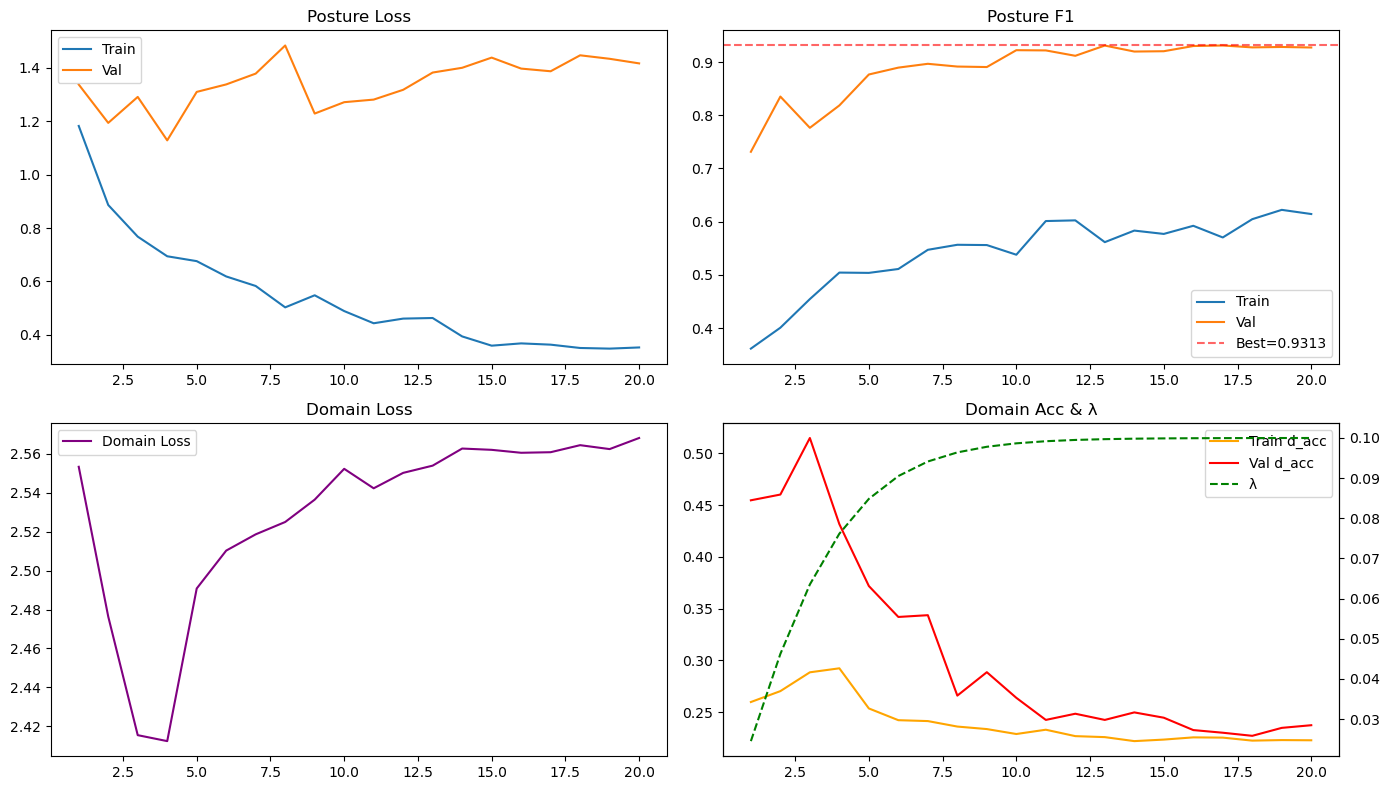

In [15]:
import matplotlib.pyplot as plt
log_df = pd.DataFrame(log)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].plot(log_df['epoch'], log_df['train_p_loss'], label='Train')
axes[0,0].plot(log_df['epoch'], log_df['val_p_loss'], label='Val')
axes[0,0].set_title('Posture Loss'); axes[0,0].legend()
axes[0,1].plot(log_df['epoch'], log_df['train_p_f1'], label='Train')
axes[0,1].plot(log_df['epoch'], log_df['val_p_f1'], label='Val')
axes[0,1].axhline(best_val_f1, color='red', ls='--', alpha=0.6, label=f'Best={best_val_f1:.4f}')
axes[0,1].set_title('Posture F1'); axes[0,1].legend()
axes[1,0].plot(log_df['epoch'], log_df['train_d_loss'], color='purple', label='Domain Loss')
axes[1,0].set_title('Domain Loss'); axes[1,0].legend()
ax2 = axes[1,1].twinx()
l1, = axes[1,1].plot(log_df['epoch'], log_df['train_d_acc'], color='orange', label='Train d_acc')
l2, = axes[1,1].plot(log_df['epoch'], log_df['val_d_acc'], color='red', label='Val d_acc')
l3, = ax2.plot(log_df['epoch'], log_df['lambda_'], color='green', ls='--', label='λ')
axes[1,1].set_title('Domain Acc & λ'); axes[1,1].legend(handles=[l1,l2,l3])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120)
plt.show()

## 📊 Classification Report

In [14]:
ckpt = torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth'), map_location=DEVICE)
eval_model = ConvNeXtDANN(MODEL_NAME, NUM_CLASSES, NUM_DOMAINS)
eval_model.load_state_dict(ckpt['model'])
eval_model = eval_model.to(DEVICE).eval()
_, val_preds, val_labels = validate(eval_model, val_loader, EPOCHS)
print(classification_report(val_labels, val_preds, target_names=CLASS_NAMES))
print(f"Best: Epoch {ckpt['epoch']}, F1={ckpt['val_f1']:.4f}, Domain Acc={ckpt.get('val_domain_acc','N/A')}")

ConvNeXtDANN: feat=1024, posture=5, domains=22


                     precision    recall  f1-score   support

 Lateral_lying_left       0.95      0.94      0.94       308
Lateral_lying_right       0.92      0.97      0.95       344
            Sitting       0.95      0.75      0.84        69
           Standing       0.99      0.99      0.99       993
      Sternal_lying       0.94      0.94      0.94       631

           accuracy                           0.96      2345
          macro avg       0.95      0.92      0.93      2345
       weighted avg       0.96      0.96      0.96      2345

Best: Epoch 17, F1=0.9313, Domain Acc=0.2302771855010661
